In [ ]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch
from tqdm.notebook import trange
import random

class TicTacToe:
    def __init__(self):
        self.row=3
        self.col=3
        self.action_size=self.row*self.col

    def init_game(self):
        return np.zeros((self.row,self.col))

    def get_next_state(self,state,action,player):
        row=action//self.col
        col=action % self.col
        state[row,col]=player
        return state

    def get_valid_moves(self,state):
        return (state.reshape(-1)==0).astype(np.uint8)

    def check_win(self,state,action):
        if(action==None):
            return False
        row = action//self.col
        col = action%self.col
        player = state[row,col]

        return (
            np.sum(state[row,:])==player*self.col or
            np.sum(state[:,col]) == player*self.row or
            np.sum(np.diag(state)) == player*self.row or
            np.sum(np.diag(np.flip(state,axis=0))) == player*self.row
        )

    def get_value_and_is_terminated(self,state,action):
        #action was taken by parent, so the player in check win will be parent.
        if self.check_win(state,action):
            return 1, True
        if np.sum(self.get_valid_moves(state))==0:
            return 0, True
        return 0,False

    def get_opponent(self,player):
        return -player

    def get_opponent_value(self,value):
        return -value

    def change_perspective(self,state,player):
        return state*player

    def get_encoded_state(self,state):
      #stack all states of -1,0,1 in seperate channels
      encoded_state = np.stack(
          (state==-1,state==0,state==1)
      ).astype(np.float32)
      return encoded_state

#MCTS
class Node:
    def __init__(self,game,args,state,parent=None,action_taken=None,prior=0):
        self.game = game
        self.args = args
        self.state = state
        self.parent:Node = parent
        self.action_taken = action_taken

        self.children = []

        self.visit_count = 0
        self.value_sum = 0
        self.prior = prior
        # CHANGED: exploration constant is configurable through args.
        self.C = self.args.get("C", np.sqrt(2))

    def is_fully_expanded(self):
        #game terminated and no children for the node
        return len(self.children)!= 0

    def select(self):
        best_child = None
        best_ucb = -np.inf

        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb>best_ucb:
                best_child = child
                best_ucb = ucb
        return best_child

    def get_ucb(self,child):
        if child.visit_count == 0:
          q_val = 0
        else:
          q_val = 1-((child.value_sum / child.visit_count)+1)/2
        return q_val + child.prior*self.C * np.sqrt(self.visit_count/(child.visit_count+1))

    def expand(self,policy):
      for action,prob in enumerate(policy):
        if prob>0:
          child_state = self.state.copy()
          child_state = self.game.get_next_state(child_state,action,1)
          child_state = self.game.change_perspective(child_state,-1)
          child = Node(self.game,self.args,child_state,self,action,prob)
          self.children.append(child)

    def backpropagate(self,value):
        self.value_sum+=value
        self.visit_count+=1
        value = self.game.get_opponent_value(value)
        if self.parent is not None:
            self.parent.backpropagate(value)

class MonteCarloTreeSearch:
    def __init__(self,game,args,model):
        self.game = game
        self.args = args
        self.model = model

    def search(self,state):
        #define root node with beginning state
        root = Node(self.game,self.args, state)
        for i in range(self.args["num_searches"]):
            node = root
            #select
            while node.is_fully_expanded():
                #select best node based on ucb
                node = node.select()

            #see if the node is a terminal state of the game, action taken was from the parent (aka the opponent)
            value, is_terminal = self.game.get_value_and_is_terminated(node.state,node.action_taken)
            #the previous line gives the value of the opponent from the childs perspecitve its the opposite
            value = self.game.get_opponent_value(value)

            if not is_terminal:
                #simulation is not there, the model gives P,v and all nodes are expanded simulataneously
                state = self.game.get_encoded_state(node.state)
                state = torch.tensor(state).unsqueeze(0)
                policy, value = self.model(state) #policy logits
                policy = torch.softmax(policy,dim=1).squeeze(0).cpu().detach().numpy()

                #apply the policy only to the valid moves
                valid_moves = self.game.get_valid_moves(node.state)
                policy*=valid_moves
                policy /= np.sum(policy)

                value = value.item()
                #expansion
                node.expand(policy)
            #backprop
            node.backpropagate(value)

        action_probs = np.zeros(self.game.action_size)
        #from the root we need to make only one move, to select the child (select the action most visited)
        for child in root.children:
            action_probs[child.action_taken]=child.visit_count
        total_visits = np.sum(action_probs)
        if total_visits > 0:
            action_probs /= total_visits
        return action_probs
        #return visit_counts



In [ ]:
class ResNet(nn.Module):
    def __init__(self,game,num_res,num_hidden):
        super().__init__()
        self.startblock=nn.Sequential(
            nn.Conv2d(3,num_hidden,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_hidden),
            nn.ReLU()
        )
        self.backbone = nn.ModuleList(
            [ResBlock(num_hidden) for i in range(num_res)]
        )

        self.policy_head = nn.Sequential(
            nn.Conv2d(num_hidden,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*game.row*game.col,game.action_size)
        )

        self.value_head = nn.Sequential(
            nn.Conv2d(num_hidden,3,kernel_size=3,padding=1),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3*game.row*game.col,1),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.startblock(x)
        for block in self.backbone:
            x = block(x)
        policy = self.policy_head(x)
        value = self.value_head(x)
        return policy,value

class ResBlock(nn.Module):
    def __init__(self,num_hidden):
        super().__init__()
        self.conv1= nn.Conv2d(num_hidden,num_hidden,kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(num_hidden)
        self.conv2 = nn.Conv2d(num_hidden,num_hidden,kernel_size=3,padding=1)
        self.bn2 = nn.BatchNorm2d(num_hidden)

    def forward(self,x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.bn2(self.conv2(x))
        x = x + residual
        x = F.relu(x)
        return x



In [ ]:
class AlphaZero:
  def __init__(self,model,optimizer,game,args):
    self.model = model
    self.optimizer = optimizer
    self.game = game
    self.args = args
    self.mcts= MonteCarloTreeSearch(game,args,model)
    self.memory_buffer=[]

  def self_play(self):
    memory_buffer = []
    player =1
    state = self.game.init_game()
    while True:
      neutral_state = self.game.change_perspective(state,player)
      mcts_probs = self.mcts.search(neutral_state)
      memory_buffer.append((self.game.get_encoded_state(neutral_state),mcts_probs,player))

      #play the game
      action = np.random.choice(self.game.action_size,p=mcts_probs)
      state = self.game.get_next_state(state,action,player)
      #check terminal condition
      value,is_terminal = self.game.get_value_and_is_terminated(state,action)
      if is_terminal:
        for hist_neutral_state,hist_mcts_probs,hist_player in memory_buffer:
          hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
          self.memory_buffer.append((
              hist_neutral_state,
              hist_mcts_probs,hist_outcome
          ))
          return
      #else flip the player around
      player = self.game.get_opponent(player)
  def train(self):
    #print(self.memory_buffer.shape)
    random_memory_buffer = random.sample(self.memory_buffer, len(self.memory_buffer))
    for batch_idx in range(0,len(random_memory_buffer),self.args['batch_size']):
      sample = random_memory_buffer[batch_idx:min(len(random_memory_buffer),batch_idx+self.args['batch_size'])]
      state,policy_targets,value_targets=zip(*sample)
      state,policy_targets,value_targets=np.array(state),np.array(policy_targets),np.array(value_targets).reshape(-1,1)
      state,policy_targets,value_targets=torch.tensor(state,dtype=torch.float32),torch.tensor(policy_targets,dtype=torch.float32),torch.tensor(value_targets,dtype = torch.float32)
      out_policy,out_value = self.model(state)
      policy_loss = F.cross_entropy(out_policy,policy_targets)
      value_loss = F.mse_loss(out_value,value_targets)
      loss = policy_loss+value_loss

      self.optimizer.zero_grad()
      loss.backward()
      self.optimizer.step()

  def learn(self):
    for iteration in range(self.args['num_iterations']):
      self.memory_buffer =[]
      #self play for some episodes to collect data
      self.model.eval()
      print(f"iteration: {iteration}")
      for episode in trange(self.args['num_episode']):
        self.self_play()

      self.model.train()
      print("training")
      for epoch in trange(self.args['num_epochs']):
        self.train()
      torch.save(self.model.state_dict(),f"model_{iteration}.pth")

In [ ]:
tct = TicTacToe()
model = ResNet(tct,4,64)
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
args = {
    'C':2,
    'num_searches':60,
    'num_iterations':3,
    'num_episode':500,
    'num_epochs':4,
    'batch_size':64
}
alphazero=AlphaZero(model,optimizer,tct,args)
alphazero.learn()

iteration: 0


  0%|          | 0/500 [00:00<?, ?it/s]

training


  0%|          | 0/4 [00:00<?, ?it/s]

iteration: 1


...

  0%|          | 0/4 [00:00<?, ?it/s]

iteration: 2


  0%|          | 0/500 [00:00<?, ?it/s]

training


  0%|          | 0/4 [00:00<?, ?it/s]

[[-1.  0. -1.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]]
[0.1877564  0.0735208  0.05171091 0.17214672 0.02345568 0.08794218
 0.26904845 0.05812768 0.07629116]
0.08537794649600983


<BarContainer object of 9 artists>

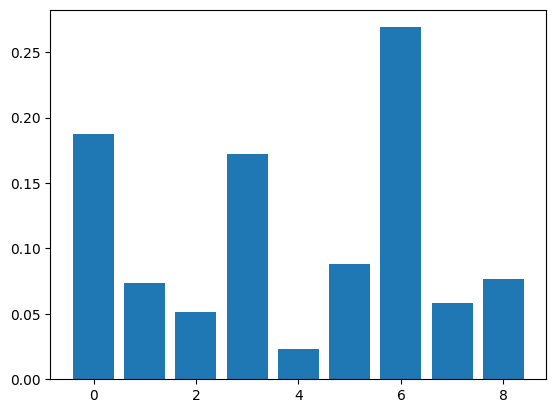

In [ ]:

game = TicTacToe()
state = game.init_game()
state = game.get_next_state(state,2,-1)
state = game.get_next_state(state,0,-1)
print(state)
encoded = game.get_encoded_state(state)
#print(encoded)

tensor = torch.tensor(encoded).unsqueeze(0)
model = ResNet(game,4,64)
model.load_state_dict(torch.load("model_2.pth"))
model.eval()
policy,value = model(tensor)
policy = torch.softmax(policy,dim=1).squeeze(0).detach().numpy()
print(policy)
print(value.item())

import matplotlib.pyplot as plt
plt.bar(range(game.action_size),policy)



In [ ]:
#GAMEPLAY
if __name__ == "__main__":
    tct = TicTacToe()
    player = 1
    args = {'num_iter': 5000, 'C': 2}
    model = ResNet(tct,4,64)
    model.eval()
    mcts = MonteCarloTreeSearch(tct,args,model)
    state = tct.init_game()

    while True:
        print(state)
        if player==1:
            valid_moves = tct.get_valid_moves(state)
            print("valid moves: ", [i for i in range(tct.action_size) if valid_moves[i]==1])
            action = int(input(f"{player}:"))
            if valid_moves[action]==0:
                print("action not valid")
                continue
        else:
            #according to any player, they are 1, and their opponent is -1
            neutral_state = tct.change_perspective(state,player)
            mcts_probs = mcts.search(neutral_state)
            action = np.argmax(mcts_probs)

        state = tct.get_next_state(state,action,player)
        value, is_terminal = tct.get_value_and_is_terminated(state,action)
        if is_terminal:
            print(state)
            if value ==1:
                print(player," won")
            else:
                print("draw")
            break
        player = tct.get_opponent(player)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
valid moves:  [0, 1, 2, 3, 4, 5, 6, 7, 8]
1:3
[[0. 0. 0.]
 [1. 0. 0.]
 [0. 0. 0.]]
[[ 0.  0.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]
valid moves:  [0, 1, 2, 4, 5, 6, 7]
1:4
[[ 0.  0.  0.]
 [ 1.  1.  0.]
 [ 0.  0. -1.]]
[[ 0.  0.  0.]
 [ 1.  1. -1.]
 [ 0.  0. -1.]]
valid moves:  [0, 1, 2, 6, 7]
1:2
[[ 0.  0.  1.]
 [ 1.  1. -1.]
 [ 0.  0. -1.]]
[[ 0.  0.  1.]
 [ 1.  1. -1.]
 [-1.  0. -1.]]
valid moves:  [0, 1, 7]
1:1
[[ 0.  1.  1.]
 [ 1.  1. -1.]
 [-1.  0. -1.]]
[[ 0.  1.  1.]
 [ 1.  1. -1.]
 [-1. -1. -1.]]
-1  won
